# Praktek PCA

## Import library dan dataset

In [ ]:
# Load beberapa library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('Loan Dataset.csv')

# Memilih variabel numerik untuk PCA
features = [
    'Annual_Income', 'Monthly_Expenses', 'Credit_Score', 
    'Total_Existing_Loan_Amount', 'Outstanding_Debt', 
    'Loan_Amount_Requested', 'Interest_Rate'
]

X = df[features]
print("Bentuk data asli:", X.shape) 

Bentuk data asli: (52000, 7)


## Melakukan scaling pada data

In [10]:
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Melakukan Standardisasi (Mean Centering & Scaling)
X_scaled = scaler.fit_transform(X)

# Menampilkan 5 baris pertama data yang sudah di-standardisasi
print(X_scaled[:5])


[[ 1.57647605 -0.16598787  0.40572196 -0.97149728  0.55834651  0.41729996
  -1.5018108 ]
 [-1.7476368   0.99789206 -1.31314806  1.65132761  0.38508732 -1.55805237
   1.665451  ]
 [-1.56138525  0.5440715  -1.80693253 -1.2503056  -0.13088109 -1.31245554
   0.92712641]
 [ 1.51914204 -0.01239894  0.62448723  1.18525893  1.57250725  1.56041947
  -0.14570442]
 [-0.05138433 -0.84903411  0.46197589  0.47251743 -0.71622244  0.27444042
  -0.06433803]]


## Mendefinisikan PCA dan menghitung PC dari data tersebut

In [11]:
# Inisialisasi model PCA
# Kita akan melihat semua komponen utamanya (7 PC)
pca = PCA()

# Melakukan perhitungan Covariance Matrix, Eigenvectors, & Eigenvalues secara otomatis
pca.fit(X_scaled)

# Mengambil nilai Explained Variance Ratio (Berdasarkan Eigenvalues)
explained_variance = pca.explained_variance_ratio_

print("Persentase Informasi setiap PC (Explained Variance):")
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var*100:.2f}%")


Persentase Informasi setiap PC (Explained Variance):
PC1: 35.33%
PC2: 14.47%
PC3: 14.36%
PC4: 14.23%
PC5: 14.07%
PC6: 5.44%
PC7: 2.09%


## Memvisualisasikan varians dari setiap PC

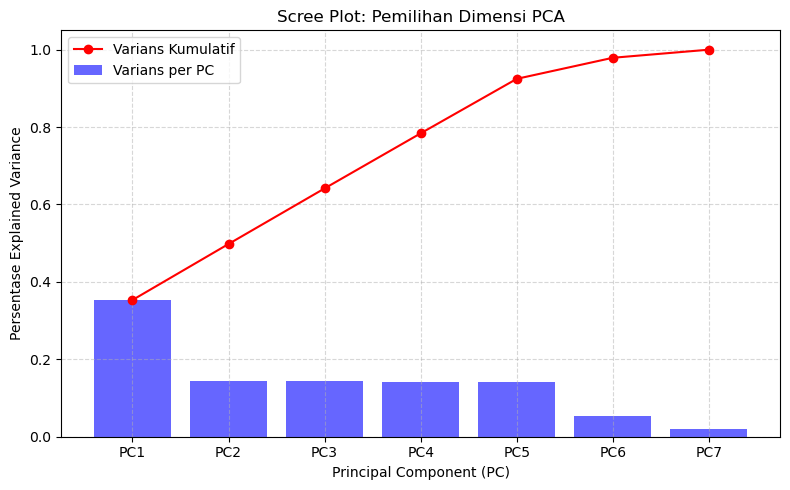

In [12]:
plt.figure(figsize=(8, 5))

# Membuat balok (Bar chart) untuk varians individu
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.6, color='b', label='Varians per PC')

# Membuat garis (Line chart) untuk Kumulatif Varians
cumulative_variance = np.cumsum(explained_variance)
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', color='r', label='Varians Kumulatif')

plt.title('Scree Plot: Pemilihan Dimensi PCA')
plt.xlabel('Principal Component (PC)')
plt.ylabel('Persentase Explained Variance')
plt.xticks(range(1, len(explained_variance)+1), [f'PC{i}' for i in range(1, len(explained_variance)+1)])
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Mengaplikasikan PCA pada dataset

In [13]:
# Menggunakan 4 komponen utama (reduksi dari 7 fitur menjadi 4 fitur)
pca_final = PCA(n_components=5)

# Transformasi (Kalikan data asli dengan Eigenvector yang dipilih)
X_pca = pca_final.fit_transform(X_scaled)

print("Bentuk data setelah Proyeksi PCA:", X_pca.shape)
# Output akan menghasilkan (baris, 4 kolom)

# Mengubah hasil ke dalam DataFrame agar lebih mudah dibaca
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
print("\nHasil Akhir Reduksi Dimensi:")
print(df_pca.head())

Bentuk data setelah Proyeksi PCA: (52000, 5)

Hasil Akhir Reduksi Dimensi:
        PC1       PC2       PC3       PC4       PC5
0  1.383975 -0.296634 -0.803747  0.389425  1.643160
1 -2.654350  1.720264  0.952452 -0.212072 -1.686971
2 -2.692003 -0.507457  0.882538  1.281906 -0.185535
3  2.175471  1.670292  0.234594 -0.814123  0.584522
4  0.386988 -0.621932 -0.227273 -0.937273 -0.378180


# Praktek Gradient Descent

In [12]:
# Mendefinisikan fungsi awal
def original_function(x):
    hasil = x**2 - 4 * x + 4
    return hasil

# Mendefinisikan fungsi turunan
def derivative_function(x):
    hasil = 2 * x - 4 
    return hasil

# Mendefinisikan x awal adalah 0 dengan error = 4, dan menggunakan learning rate 0.001
x = 0
learning_rate = 0.001

# Melakukan iterasi untuk gradient descent
for _ in range(1000):
    y = original_function(x)
    x = x - learning_rate * derivative_function(x)
    if _ % 10 == 0 :
        print(f"Pada iterasi ke {_} dan titik {x}, error yang didapat adalah {y}")

Pada iterasi ke 0 dan titik 0.004, error yang didapat adalah 4
Pada iterasi ke 10 dan titik 0.04356262946950895, error yang didapat adalah 3.843003828105371
Pada iterasi ke 20 dan titik 0.08234108977541989, error yang didapat adalah 3.692169605708134
Pada iterasi ke 30 dan titik 0.12035092390072921, error yang didapat adalah 3.5472554821876643
Pada iterasi ke 40 dan titik 0.15760736675164116, error yang didapat adalah 3.4080290993287394
Pada iterasi ke 50 dan titik 0.19412535126394465, error yang didapat adalah 3.274267218753711
Pada iterasi ke 60 dan titik 0.2299195143883556, error yang didapat adalah 3.1457553639776092
Pada iterasi ke 70 dan titik 0.2650042029572243, error yang didapat adalah 3.0222874765122394
Pada iterasi ke 80 dan titik 0.2993934794349592, error yang didapat adalah 2.903665585467864
Pada iterasi ke 90 dan titik 0.33310112755447097, error yang didapat adalah 2.7896994901227066
Pada iterasi ke 100 dan titik 0.3661406578418982, error yang didapat adalah 2.68020645495